# Cosimita: spacecraft orbit and attitude

This is the first notebook for *cosimita*, the toy inertial-frame simulator that
flies the toy Compton detector from the earlier tutorials around a toy Earth. This
notebook only covers the **geometry** laid down in this PR -- the orbit, the
attitude, and the occultation by the Earth. Nothing here touches photons or the
detector; that comes in a later PR, which will build on the objects introduced
here.

**This is flatland.** Everything below is 2D:

- The Earth is a **circle**, not a sphere.
- The sky is a **1D circle of directions** -- an angle, not a solid angle.
- An "orbit" is a **planar ellipse**: Kepler's problem confined to a plane, with no
  inclination and no ascending node to speak of.

If your intuition is 3D, set it aside for this notebook. Every angle below is
measured **counterclockwise (CCW) from the inertial +X axis**, and the Earth sits
at the origin of that inertial frame.

## 1. The inertial frame and the Earth

The inertial frame's origin is the Earth's centre. A spacecraft at orbital radius
`r` and orbital position angle `theta` (both CCW from +X) sits at
`(r cos(theta), r sin(theta))`. `Earth.radius` defaults to astropy's nominal
`R_earth`. Let's draw it:

Earth radius R_E = 6378.1 km


<Axes: xlabel='X [km]', ylabel='Y [km]'>

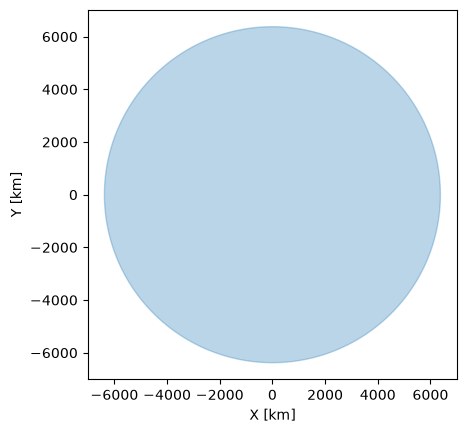

In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from gammaraytoys.sims import Earth

earth = Earth()
print(f"Earth radius R_E = {earth.radius}")

earth.plot()

### The Earth's angular radius

From a spacecraft at distance `r` from the Earth's centre, the Earth subtends a
half-angle `rho = arcsin(R_E / r)` on the sky (`Earth.angular_radius`). It is
always below 90 degrees, since the spacecraft always sits above the surface.
Let's check it against the formula computed by hand, and see how quickly it
shrinks as the orbit gets bigger:

In [2]:
for altitude in [100*u.km, 500*u.km, 35786*u.km]:
    r = earth.radius + altitude
    rho = earth.angular_radius(r)
    rho_by_hand = (np.arcsin((earth.radius / r).to_value(u.dimensionless_unscaled)) * u.rad).to(u.deg)
    print(f"altitude = {altitude:>10}   r = {r:>10.1f}   "
          f"rho = {rho:7.3f}   rho by hand = {rho_by_hand:7.3f}")

altitude =      100.0 km   r =     6478.1 km   rho =  79.920 deg   rho by hand =  79.920 deg
altitude =      500.0 km   r =     6878.1 km   rho =  68.019 deg   rho by hand =  68.019 deg
altitude =    35786.0 km   r =    42164.1 km   rho =   8.700 deg   rho by hand =   8.700 deg


Even at geostationary altitude (35786 km) the Earth still covers about 8.7 degrees
of sky -- more than 17 full Moons across. To get down to about a degree, as the
plan's intuition suggests, you have to go much further out still, to roughly lunar
distance:

In [3]:
r_moon = 384400*u.km
rho_moon = earth.angular_radius(r_moon)
print(f"At lunar distance ({r_moon}), rho = {rho_moon:.3f}")

At lunar distance (384400.0 km), rho = 0.951 deg


## 2. Occultation geometry

The Earth blocks any source whose sky direction falls within `rho` of **nadir** --
straight down from the spacecraft, `nadir = orbit_angle + 180 deg`. That is a
wedge of the sky, of half-width `rho`, centred on nadir.
`Earth.is_occulted(sky_angle, orbit_angle, orbit_radius)` returns `True` for any
sky direction inside that wedge.

Let's draw it: a spacecraft in a low orbit, the Earth, the blocked wedge shaded
red, and a few sources at fixed sky angles, some inside the wedge (occulted) and
some outside (visible).

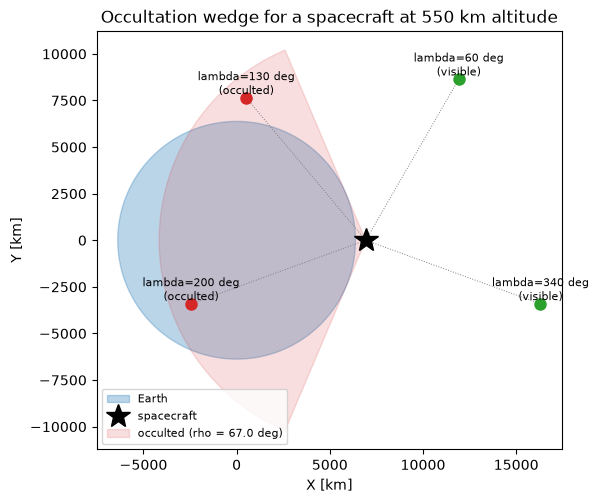

In [4]:
orbit_angle = 0*u.deg
orbit_radius = earth.radius + 550*u.km
rho = earth.angular_radius(orbit_radius)
nadir = orbit_angle + 180*u.deg

fig, ax = plt.subplots(figsize=(6, 6))
earth.plot(ax=ax)

sc_x = (orbit_radius * np.cos(orbit_angle)).to_value(u.km)
sc_y = (orbit_radius * np.sin(orbit_angle)).to_value(u.km)
ax.plot(sc_x, sc_y, '*', color='black', ms=18, label='spacecraft', zorder=5)

# Shade the blocked wedge as seen from the spacecraft: a triangle running from
# the spacecraft out past the Earth, spanning nadir +/- rho.
wedge_len = 1.6 * orbit_radius.to_value(u.km)
wedge_edges = np.radians(np.linspace((nadir - rho).to_value(u.deg),
                                     (nadir + rho).to_value(u.deg), 60))
wedge_x = np.concatenate([[sc_x], sc_x + wedge_len * np.cos(wedge_edges), [sc_x]])
wedge_y = np.concatenate([[sc_y], sc_y + wedge_len * np.sin(wedge_edges), [sc_y]])
ax.fill(wedge_x, wedge_y, color='tab:red', alpha=0.15, label=f'occulted (rho = {rho:.1f})')

# A few sources at fixed inertial sky angles.
sky_angles = [130, 200, 340, 60] * u.deg
for lam in sky_angles:
    occulted = earth.is_occulted(lam, orbit_angle, orbit_radius)
    mx = sc_x + 0.9 * wedge_len * np.cos(lam.to_value(u.rad))
    my = sc_y + 0.9 * wedge_len * np.sin(lam.to_value(u.rad))
    ax.plot([sc_x, mx], [sc_y, my], ':', color='gray', lw=0.7)
    color = 'tab:red' if occulted else 'tab:green'
    ax.plot(mx, my, 'o', color=color, ms=8)
    label = 'occulted' if occulted else 'visible'
    ax.annotate(f"lambda={lam:.0f}\n({label})", (mx, my), fontsize=8, ha='center', va='bottom')

ax.set_aspect('equal')
ax.legend(loc='lower left', fontsize=8)
ax.set_title('Occultation wedge for a spacecraft at 550 km altitude');

Now let's check that `is_occulted` agrees with the picture right at the wedge's
two edges, approaching from both sides. A tiny step toward nadir should occult;
the same tiny step away from nadir should not:

In [5]:
eps = 1e-6 * u.deg

for edge_name, edge in [('lower edge (nadir - rho)', nadir - rho),
                        ('upper edge (nadir + rho)', nadir + rho)]:
    # Sign that moves us from this edge toward nadir.
    toward_sign = np.sign((nadir - edge).to_value(u.deg)) or 1.0
    toward_nadir = edge + toward_sign * eps
    away_from_nadir = edge - toward_sign * eps
    print(edge_name)
    print(f"  {eps:.0e} toward nadir  -> occulted = "
          f"{earth.is_occulted(toward_nadir, orbit_angle, orbit_radius)}")
    print(f"  {eps:.0e} away from nadir -> occulted = "
          f"{earth.is_occulted(away_from_nadir, orbit_angle, orbit_radius)}")

# And exactly at the edge, the boundary itself is not occulted (strict '<').
print(f"exactly at the edge -> occulted = {earth.is_occulted(nadir - rho, orbit_angle, orbit_radius)}")

lower edge (nadir - rho)
  1e-06 deg toward nadir  -> occulted = True
  1e-06 deg away from nadir -> occulted = False
upper edge (nadir + rho)
  1e-06 deg toward nadir  -> occulted = True
  1e-06 deg away from nadir -> occulted = False
exactly at the edge -> occulted = False


## 3. Generating an orbit

`SpacecraftHistory.from_elliptical_orbit` solves Kepler's equation for a given
semi-major axis and eccentricity, and writes out a row per `time_step` -- a
circular orbit is just `eccentricity = 0`, the default. Let's generate a
low, circular orbit (550 km altitude, close to COSI's) and plot it to scale
with the Earth:

nintervals = 191
total_livetime = 5738.947141999026 s


<Axes: xlabel='X [km]', ylabel='Y [km]'>

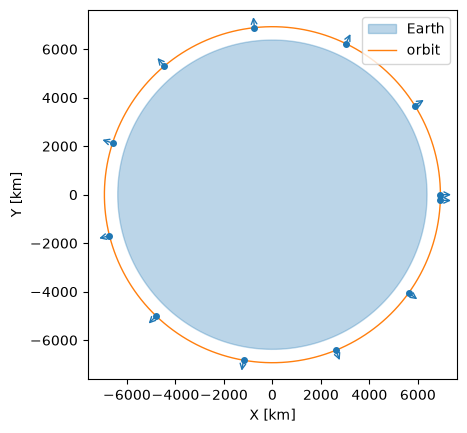

In [6]:
from gammaraytoys.sims import SpacecraftHistory

altitude = 550 * u.km
semi_major_axis = earth.radius + altitude

history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis=semi_major_axis, time_step=30*u.s)

print(f"nintervals = {history.nintervals}")
print(f"total_livetime = {history.total_livetime}")

history.plot()

### The `.ori` file, in the raw

A `SpacecraftHistory` is, underneath everything, just rows of
`(time, orbit_radius, orbit_angle, attitude, uptime)` written to a `.ori` file --
the format from the plan's Section 4.1. Knowing exactly what is on disk is more
useful to a reviewer than any description of it, so let's write this orbit out
and look at the first few raw lines:

In [7]:
import tempfile
import pathlib

tmp_dir = pathlib.Path(tempfile.mkdtemp())
ori_path = tmp_dir / 'circular_orbit.ori'
history.write(ori_path)

with open(ori_path) as f:
    for _ in range(8):
        line = f.readline()
        if not line:
            break
        print(line.rstrip())

time_s,orbit_radius_km,orbit_angle_deg,attitude_deg,uptime_s
0.0,6928.1,0.0,0.0,30.046843675387574
30.046843675387574,6928.1,1.8848167539267016,1.8848167539267016,30.046843675387574
60.09368735077515,6928.1,3.769633507853403,3.769633507853403,30.04684367538757
90.14053102616272,6928.1,5.654450261780104,5.654450261780104,30.046843675387578
120.1873747015503,6928.1,7.539267015706806,7.539267015706806,30.046843675387564
150.23421837693786,6928.1,9.424083769633507,9.424083769633507,30.046843675387578
180.28106205232544,6928.1,11.308900523560208,11.308900523560208,30.046843675387578


## 4. Interval semantics -- the part most easily got wrong

`N` rows in a history define `N - 1` **intervals**, not `N`. Interval `i` spans
`[t_i, t_{i+1})` and takes **both** its pose (`orbit_radius`, `orbit_angle`,
`attitude`) **and** its livetime (`uptime_s`) from row `i`. Row `N`, the last one,
is a pure **terminator**: it exists only to supply `t_N`, the timestamp that
closes the final interval. Its pose and its `uptime_s` are never read by
`__iter__`, `total_livetime`, or anything else -- a reader must not require them
to be meaningful.

One consequence worth internalising: `uptime_s` is **forward-looking**. Row `i`'s
`uptime_s` is the live time during `[t_i, t_{i+1})`, the interval that *starts* at
row `i` -- not the live time since row `i-1`.

First, the row-count/interval-count relationship, on a small hand-built history
with 4 rows:

In [8]:
small_history = SpacecraftHistory(
    time=np.array([0.0, 10.0, 20.0, 30.0]) * u.s,
    orbit_radius=np.array([7000.0, 7100.0, 7200.0, 7300.0]) * u.km,
    orbit_angle=np.array([0.0, 5.0, 10.0, 15.0]) * u.deg,
    attitude=np.array([90.0, 95.0, 100.0, 105.0]) * u.deg,
    uptime=np.array([8.0, 6.0, 9.0, 0.0]) * u.s,
)

n_rows = 4
print(f"rows = {n_rows}, nintervals = {small_history.nintervals}")
assert small_history.nintervals == n_rows - 1

rows = 4, nintervals = 3


Now the part that is easy to get wrong: build a history whose terminator row
holds obvious garbage (`999999`) in every field except its timestamp, and check
that the garbage never leaks into an interval or into `total_livetime`:

In [9]:
GARBAGE = 999999.0

garbage_history = SpacecraftHistory(
    time=np.array([0.0, 10.0, 20.0, 30.0]) * u.s,
    orbit_radius=np.array([7000.0, 7100.0, 7200.0, GARBAGE]) * u.km,
    orbit_angle=np.array([0.0, 5.0, 10.0, GARBAGE]) * u.deg,
    attitude=np.array([90.0, 95.0, 100.0, GARBAGE]) * u.deg,
    uptime=np.array([8.0, 6.0, 9.0, GARBAGE]) * u.s,
)

print(f"nintervals = {garbage_history.nintervals}")
print(f"total_livetime = {garbage_history.total_livetime}")
print()
for interval in garbage_history:
    print(interval)

for interval in garbage_history:
    for value in (interval.orbit_radius.value, interval.orbit_angle.value,
                 interval.attitude.value, interval.livetime.value):
        assert value != GARBAGE
assert garbage_history.total_livetime.to_value(u.s) != GARBAGE

print()
print("The terminator's garbage never appears in any interval, and never "
     "reaches total_livetime.")

nintervals = 3
total_livetime = 23.0 s

SpacecraftInterval(start_time=<Quantity 0. s>, stop_time=<Quantity 10. s>, livetime=<Quantity 8. s>, orbit_radius=<Quantity 7000. km>, orbit_angle=<Quantity 0. deg>, attitude=<Quantity 90. deg>)
SpacecraftInterval(start_time=<Quantity 10. s>, stop_time=<Quantity 20. s>, livetime=<Quantity 6. s>, orbit_radius=<Quantity 7100. km>, orbit_angle=<Quantity 5. deg>, attitude=<Quantity 95. deg>)
SpacecraftInterval(start_time=<Quantity 20. s>, stop_time=<Quantity 30. s>, livetime=<Quantity 9. s>, orbit_radius=<Quantity 7200. km>, orbit_angle=<Quantity 10. deg>, attitude=<Quantity 100. deg>)

The terminator's garbage never appears in any interval, and never reaches total_livetime.


## 5. Observation strategies

Attitude `A` is the inertial angle of the detector's **+y** axis, CCW from
inertial +X -- not the spacecraft's velocity or position. An
`observation_strategy` is just a callable `(time, orbit_radius, orbit_angle) ->
attitude`, evaluated at every generated row. Let's put the same circular orbit
under four strategies and draw the detector's +y direction as an arrow at several
points around the orbit, so the difference is visible at a glance:

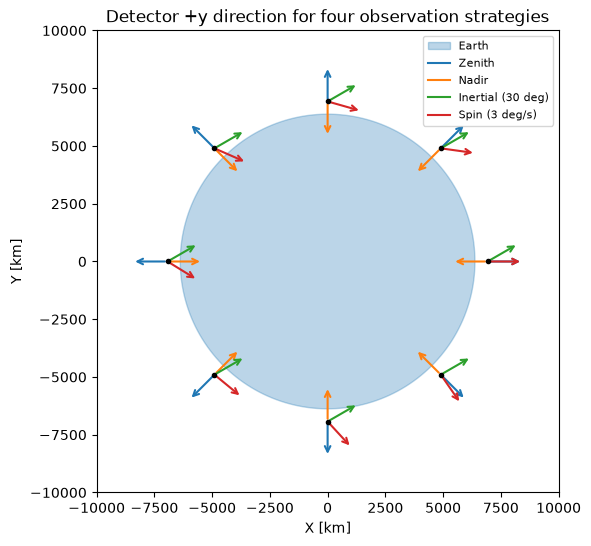

In [10]:
from astropy.constants import G, M_earth
from gammaraytoys.sims import ZenithPointing, NadirPointing, InertialPointing, SpinPointing

strategies = {
    'Zenith': ZenithPointing(),
    'Nadir': NadirPointing(),
    'Inertial (30 deg)': InertialPointing(30*u.deg),
    'Spin (3 deg/s)': SpinPointing(3*u.deg/u.s),
}
colors = {'Zenith': 'tab:blue', 'Nadir': 'tab:orange',
         'Inertial (30 deg)': 'tab:green', 'Spin (3 deg/s)': 'tab:red'}

# Same spacecraft positions for every strategy -- only the attitude differs.
r = semi_major_axis
theta_positions = np.linspace(0, 360, 8, endpoint=False) * u.deg
x = (r * np.cos(theta_positions)).to_value(u.km)
y = (r * np.sin(theta_positions)).to_value(u.km)

# SpinPointing needs an absolute time per position; for this circular orbit the
# angular rate is constant, so theta = n * t with the mean motion n.
mu = (G * M_earth).to(u.km**3 / u.s**2)
n = np.sqrt(mu / r**3)  # rad/s
t_positions = (theta_positions.to_value(u.rad) / n.to_value(1/u.s)) * u.s
r_positions = np.full(theta_positions.shape, r.to_value(u.km)) * u.km

fig, ax = plt.subplots(figsize=(6, 6))
earth.plot(ax=ax)
ax.plot(x, y, 'o', color='black', ms=3, zorder=5)

arrow_len = 0.22 * r.to_value(u.km)
for name, strategy in strategies.items():
    attitude = strategy(t_positions, r_positions, theta_positions)
    attitude_rad = attitude.to_value(u.rad)
    for xi, yi, ai in zip(x, y, attitude_rad):
        ax.annotate('', xytext=(xi, yi),
                   xy=(xi + arrow_len * np.cos(ai), yi + arrow_len * np.sin(ai)),
                   arrowprops=dict(arrowstyle='->', color=colors[name], lw=1.5))
    ax.plot([], [], color=colors[name], label=name)  # legend proxy

ax.set_aspect('equal')
ax.set_xlim(-10000, 10000)
ax.set_ylim(-10000, 10000)
ax.legend(loc='upper right', fontsize=8)
ax.set_title("Detector +y direction for four observation strategies");

`attitude` and `orbit_angle` are deliberately left **unwrapped**: they grow past
360 degrees rather than being wrapped back into `[0, 360)`. That matters for
anything that differentiates them (like the angular momentum check in the next
section) or accumulates a spin over many orbits. A `SpinPointing` history makes
this obvious immediately -- after a single orbital period at 3 deg/s the attitude
is already well past 360 degrees:

In [11]:
spin_history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis=semi_major_axis, time_step=30*u.s,
    observation_strategy=SpinPointing(3*u.deg/u.s))

attitudes = u.Quantity([interval.attitude for interval in spin_history])
orbit_angles = u.Quantity([interval.orbit_angle for interval in spin_history])
print(f"attitude:    {attitudes.min():.1f} to {attitudes.max():.1f} (unwrapped)")
print(f"orbit_angle: {orbit_angles.min():.1f} to {orbit_angles.max():.1f} (unwrapped)")

attitude:    0.0 deg to 17126.7 deg (unwrapped)
orbit_angle: 0.0 deg to 358.1 deg (unwrapped)


### `TargetedPointing`: tracking a source through occultation

The four strategies above never look at anything outside the spacecraft's own
pose. `TargetedPointing(sky_angle, earth)` is different: it points the
detector's +y axis directly at a fixed-sky-angle source (`A = sky_angle`,
putting the source exactly on-axis, `Nu = 0`) whenever that source clears the
Earth's limb, and falls back to `ZenithPointing` (`A = orbit_angle`) whenever
the source is occulted. It needs its own `Earth` instance -- not a default --
because it is the one deciding occultation, and that `Earth` must be the same
one the resulting history (and later, the simulation) is checked against.

Unlike the other four strategies, this one's attitude is **not** smooth: it
jumps every time the target rises or sets, the way a real spacecraft slews
onto a target and slews back off it. Let's fly the same 550 km circular orbit
under this strategy and plot the attitude over one orbit, shading the
intervals during which the target is occulted, so the switch between tracking
and the zenith fallback is visible as a sawtooth:


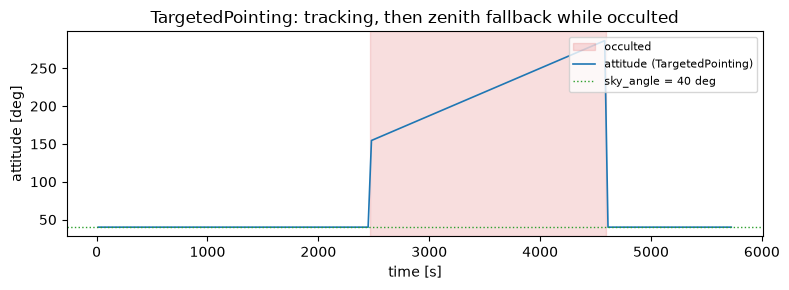

In [12]:
from gammaraytoys.sims import TargetedPointing

target_sky_angle = 40 * u.deg

targeted_history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis=semi_major_axis, time_step=30*u.s,
    observation_strategy=TargetedPointing(target_sky_angle, earth), earth=earth)

intervals_tgt = list(targeted_history)
t_tgt = u.Quantity([iv.mid_time for iv in intervals_tgt])
attitude_tgt = u.Quantity([iv.attitude for iv in intervals_tgt])
orbit_angle_tgt = u.Quantity([iv.orbit_angle for iv in intervals_tgt])
orbit_radius_tgt = u.Quantity([iv.orbit_radius for iv in intervals_tgt])
occulted_tgt = earth.is_occulted(target_sky_angle, orbit_angle_tgt, orbit_radius_tgt)

# Interval edges, for shading: each interval's start_time, plus the final
# interval's stop_time to close the last one.
t_edges = u.Quantity([iv.start_time for iv in intervals_tgt] + [intervals_tgt[-1].stop_time])

fig, ax = plt.subplots(figsize=(8, 3))

# Shade the *runs* of occulted intervals, merged so each contiguous
# stretch of occultation renders as one solid band rather than many tiny
# abutting rectangles (which show antialiasing seams between them).
occulted_arr = np.asarray(occulted_tgt)
run_edges = np.flatnonzero(np.diff(np.concatenate(([False], occulted_arr, [False]))))
for k, (start, stop) in enumerate(run_edges.reshape(-1, 2)):
    ax.axvspan(t_edges[start].to_value(u.s), t_edges[stop].to_value(u.s),
               color='tab:red', alpha=0.15, label='occulted' if k == 0 else None)

ax.plot(t_tgt.to_value(u.s), attitude_tgt.to_value(u.deg), '-', color='tab:blue', lw=1.2,
       label='attitude (TargetedPointing)')
ax.axhline(target_sky_angle.to_value(u.deg), color='tab:green', ls=':', lw=1,
          label=f'sky_angle = {target_sky_angle:.0f}')

ax.set_xlabel('time [s]')
ax.set_ylabel('attitude [deg]')
ax.set_title('TargetedPointing: tracking, then zenith fallback while occulted')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()


In [13]:
# The two regimes are exactly the two identities from Section 3.4: locked
# onto the source (A == sky_angle, Nu == 0) while visible, and matching
# ZenithPointing (A == orbit_angle) while occulted.
visible = ~occulted_tgt
print(f"visible intervals:  {np.sum(visible):3d} / {len(visible)}, "
     f"max |A - sky_angle| = {np.max(np.abs(attitude_tgt[visible] - target_sky_angle)):.2e}")
print(f"occulted intervals: {np.sum(occulted_tgt):3d} / {len(visible)}, "
     f"max |A - orbit_angle| = "
     f"{np.max(np.abs(attitude_tgt[occulted_tgt] - orbit_angle_tgt[occulted_tgt])):.2e}")

assert np.any(visible) and np.any(occulted_tgt)
assert np.allclose(attitude_tgt[visible].to_value(u.deg), target_sky_angle.to_value(u.deg))
assert np.allclose(attitude_tgt[occulted_tgt].to_value(u.deg),
                   orbit_angle_tgt[occulted_tgt].to_value(u.deg))


visible intervals:  120 / 191, max |A - sky_angle| = 0.00e+00 deg
occulted intervals:  71 / 191, max |A - orbit_angle| = 0.00e+00 deg


## 6. An eccentric orbit, and why it is a real Kepler solve

`from_elliptical_orbit` solves Kepler's equation by Newton iteration on the
eccentric anomaly, rather than approximating the orbit as uniform-in-angle. Two
checks distinguish a real Kepler orbit from that cheaper approximation:

- **`r` is not a sinusoid.** The spacecraft moves fastest near periapsis and
  slowest near apoapsis (Kepler's second law), so `r(t)` is lopsided, not a clean
  sine wave.
- **Specific angular momentum `h = r^2 dtheta/dt` is conserved.** For an ellipse
  with semi-major axis `a` and eccentricity `e`, the closed form is
  `h = sqrt(mu a (1 - e^2))`.

Let's generate a moderately eccentric orbit and check both, plus the orbital
period against `2 pi sqrt(a^3 / mu)`:

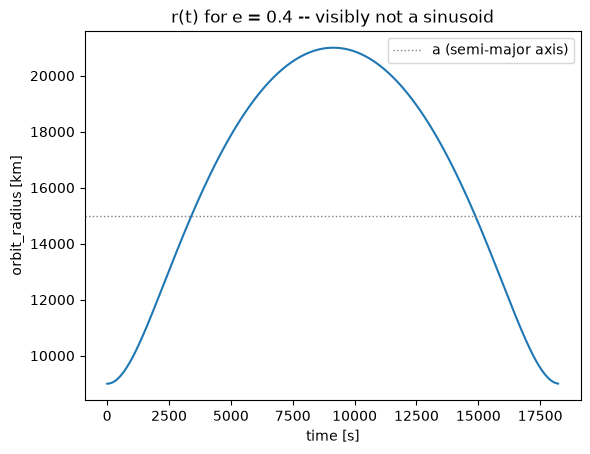

In [14]:
a = 15000 * u.km
e = 0.4

ecc_history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis=a, eccentricity=e, time_step=60*u.s)

intervals = list(ecc_history)
t = u.Quantity([iv.start_time for iv in intervals])
r_ecc = u.Quantity([iv.orbit_radius for iv in intervals])
theta_ecc = u.Quantity([iv.orbit_angle for iv in intervals])

fig, ax = plt.subplots()
ax.plot(t.to_value(u.s), r_ecc.to_value(u.km))
ax.axhline(a.to_value(u.km), color='gray', ls=':', lw=1, label='a (semi-major axis)')
ax.set_xlabel('time [s]')
ax.set_ylabel('orbit_radius [km]')
ax.set_title(f'r(t) for e = {e} -- visibly not a sinusoid')
ax.legend();

h (numeric, interior points): mean = 70871.0 km2 / s, std = 5.25 km2 / s
h (closed form)             : 70868.6 km2 / s
relative difference         : 3.32e-05


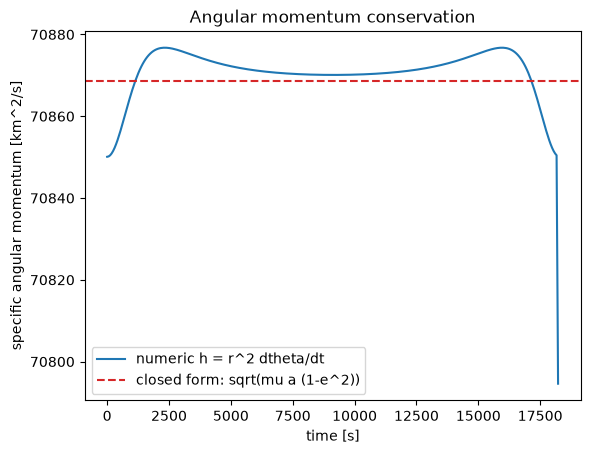

In [15]:
mu = (G * M_earth).to(u.km**3 / u.s**2)

dtheta_dt = np.gradient(theta_ecc.to_value(u.rad), t.to_value(u.s)) * u.rad / u.s
h = (r_ecc**2 * dtheta_dt).to(u.km**2 / u.s, equivalencies=u.dimensionless_angles())
h_closed = np.sqrt(mu * a * (1 - e**2)).to(u.km**2 / u.s)

# Trim the two points at each end, where a finite-difference gradient is least
# accurate.
h_interior = h[2:-2]

fig, ax = plt.subplots()
ax.plot(t.to_value(u.s), h.to_value(u.km**2/u.s), label='numeric h = r^2 dtheta/dt')
ax.axhline(h_closed.to_value(u.km**2/u.s), color='tab:red', ls='--',
          label='closed form: sqrt(mu a (1-e^2))')
ax.set_xlabel('time [s]')
ax.set_ylabel('specific angular momentum [km^2/s]')
ax.legend()
ax.set_title('Angular momentum conservation')

print(f"h (numeric, interior points): mean = {np.mean(h_interior):.1f}, "
     f"std = {np.std(h_interior):.2f}")
print(f"h (closed form)             : {h_closed:.1f}")
print(f"relative difference         : {abs(np.mean(h_interior) - h_closed) / h_closed:.2e}")

In [16]:
period_numeric = intervals[-1].stop_time  # duration defaults to one full period
period_closed = (2 * np.pi * np.sqrt(a**3 / mu)).to(u.s)

print(f"period (from generated duration): {period_numeric:.3f}")
print(f"period (closed form)            : {period_closed:.3f}")
print(f"relative difference             : {abs(period_numeric - period_closed) / period_closed:.2e}")

assert abs(period_numeric - period_closed) / period_closed < 1e-9

period (from generated duration): 18283.018 s
period (closed form)            : 18283.018 s
relative difference             : 0.00e+00


## 7. Occultation over an orbit

Putting it together: for a source at a fixed inertial `sky_angle`, how much of a
circular orbit is spent occulted? For a circular orbit the answer has a clean
closed form -- the blocked wedge has angular width `2 rho` out of the `2 pi` the
spacecraft sweeps each orbit, so the occulted **duty cycle** is `rho / pi`
(`rho` in radians), independent of where the source sits on the sky. This is
exactly what the next PR's photon simulation will use to scale a source's
visible livetime.

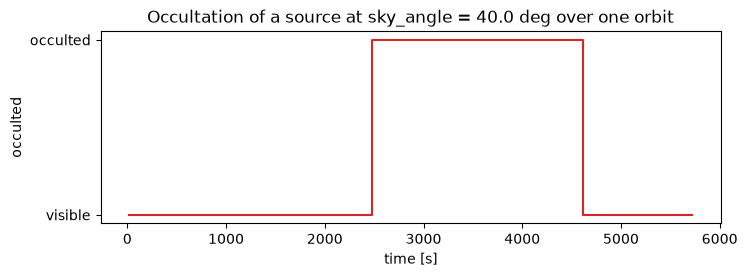

In [17]:
sky_angle = 40 * u.deg

circ_intervals = list(history)  # the 550 km circular orbit from Section 3
t_circ = u.Quantity([iv.mid_time for iv in circ_intervals])
orbit_angle_circ = u.Quantity([iv.orbit_angle for iv in circ_intervals])
orbit_radius_circ = u.Quantity([iv.orbit_radius for iv in circ_intervals])

occulted = earth.is_occulted(sky_angle, orbit_angle_circ, orbit_radius_circ)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.step(t_circ.to_value(u.s), occulted.astype(int), where='post', color='tab:red')
ax.set_xlabel('time [s]')
ax.set_ylabel('occulted')
ax.set_yticks([0, 1])
ax.set_yticklabels(['visible', 'occulted'])
ax.set_title(f'Occultation of a source at sky_angle = {sky_angle} over one orbit');

In [18]:
rho = earth.angular_radius(semi_major_axis)
duty_cycle_numeric = np.mean(occulted)
duty_cycle_analytic = (rho / (180 * u.deg)).to_value(u.dimensionless_unscaled)  # rho/pi, rho in radians

print(f"rho                          = {rho:.3f}")
print(f"occulted duty cycle, numeric = {duty_cycle_numeric:.4f}")
print(f"occulted duty cycle, rho/pi  = {duty_cycle_analytic:.4f}")
print(f"relative difference          = {abs(duty_cycle_numeric - duty_cycle_analytic) / duty_cycle_analytic:.2%}")

rho                          = 67.016 deg
occulted duty cycle, numeric = 0.3717
occulted duty cycle, rho/pi  = 0.3723
relative difference          = 0.16%


The two agree to well under a percent -- the small remaining difference is just
the finite `time_step` used to sample the orbit. This closes the loop on the
geometry this PR introduces: an inertial frame and an Earth, an orbit generated
from a real Kepler solve, an attitude history from an observation strategy, and
occultation checked against that history. The next notebook puts photons on top
of it.